# Study 777 — Black-Friday-Retail 🛍️

*For the curious.* Everyone *knows* you buy retail into Black Friday — the sector runs up on holiday-sales hopes, then sells the news. We put 20 Black Fridays (2006→2025) on the stand and asked the tape two plain questions: **does the retail ETF (XRT) rally into Black Friday?** and **does it fade after?** The answer is more interesting than the usual folklore bust.

## The claim, and why it's a clean test

Black Friday (the Friday after US Thanksgiving) is the year's biggest shopping catalyst and its date is **fixed by statute** — the day after the fourth Thursday of November, known years ahead. So *buy K sessions before, sell on the day* is calendar-known and zero-look-ahead. We measure XRT's **abnormal** return (XRT − SPY, total-return) so we net out the market's own November drift and see only retail's *relative* move.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from black_friday_retail import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching XRT + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} Black Fridays resolved")


panel loaded; 20 of 20 Black Fridays resolved


## The Black-Friday calendar we test (day after the 4th Thursday of November)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['year', 'black_friday'])

,year,black_friday
0,2006,2006-11-24
1,2007,2007-11-23
2,2008,2008-11-28
3,2009,2009-11-27
4,2010,2010-11-26
5,2011,2011-11-25
6,2012,2012-11-23
7,2013,2013-11-29
8,2014,2014-11-28
9,2015,2015-11-27


## The picture: mean cumulative abnormal return around Black Friday

Offset 0 is Black Friday. Left of zero is the *run-up* (the supposed rally in); right of zero is the *fade* window.

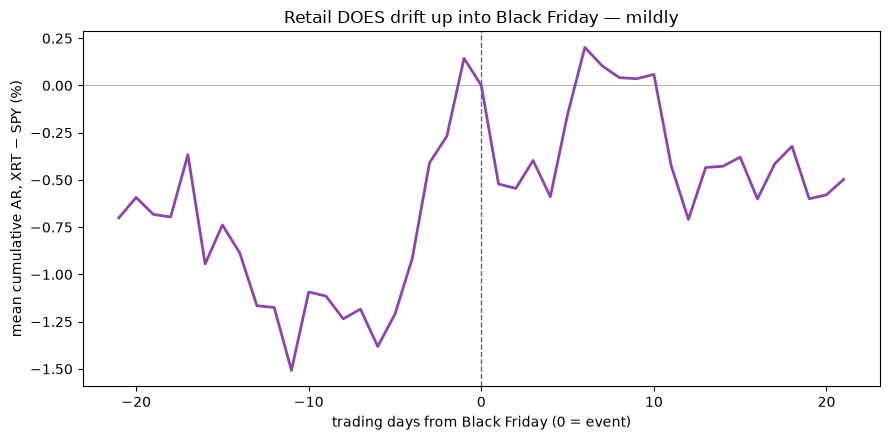

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#8e44ad', lw=2)
ax.set_xlabel('trading days from Black Friday (0 = event)')
ax.set_ylabel('mean cumulative AR, XRT − SPY (%)')
ax.set_title('Retail DOES drift up into Black Friday — mildly')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 2-week run-up | **+1.33%** | **+1.58** | 13/20 |
| 1-month run-up | +1.14% | +1.09 | 12/20 |
| 2-week fade | +0.06% | +0.08 | 9/20 |
| 1-month fade | -0.50% | -0.43 | 9/20 |

The run-up points the **right way** for once: in the last two weeks *into* Black Friday XRT beats SPY by +1.33% on average, hitting 13 of 20 years. But it's mild — *t* is only +1.58 (short of significance) — and it *weakens* if you stretch to a month. And the 'sell the news' fade? A clean zero (both cuts |*t*| < 0.5).

In [4]:
rows = [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk fade','post_s'),('1mo fade','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<12s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

2wk run-up   n=20  mean=+1.333%  t=+1.585  hit 13/20
1mo run-up   n=20  mean=+1.138%  t=+1.086  hit 12/20
2wk fade     n=20  mean=+0.059%  t=+0.081  hit 9/20
1mo fade     n=20  mean=-0.497%  t=-0.435  hit 9/20


## So what?

Retail really *does* drift up into Black-Friday week — the right direction, and unusual versus random windows (the quants' notebook shows only ~2.6% of random fortnights were this positive). But the effect is small, only *marginally* significant (*t* ≈ 1.6), fades at a longer lookback, and comes with **no** 'sell the news' reversal to pair it with. Verdict: **Weak signal, Mirage tradability** — a suggestive curiosity, not a bankable trade. The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control.